# Phase 2 — EDA, Preprocessing & Sliding Window
**Project:** Adaptive Reinforcement Learning Firewall  
**Dataset:** NSL-KDD (KDDTrain+.csv / KDDTest+.csv)  
**Output:** `X_train.npy`, `y_train.npy`, `X_test.npy`, `y_test.npy` → `data/processed/`

In [1]:
# ── Cell 1: Imports ───────────────────────────────────────────────────────────
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

print(f"Python  : {sys.version.split()[0]}")
print(f"NumPy   : {np.__version__}")
print(f"pandas  : {pd.__version__}")
print("All imports OK.")

Python  : 3.14.3
NumPy   : 2.4.3
pandas  : 3.0.1
All imports OK.


In [2]:
# ── Cell 2: Paths ─────────────────────────────────────────────────────────────
DATA_ROOT = os.environ.get("RL_FIREWALL_DATA", "./data")
RAW_DIR  = os.path.join(DATA_ROOT, "raw")
PROC_DIR = os.path.join(DATA_ROOT, "processed")

TRAIN_CSV = os.path.join(RAW_DIR, "KDDTrain+.csv")
TEST_CSV  = os.path.join(RAW_DIR, "KDDTest+.csv")

os.makedirs(PROC_DIR, exist_ok=True)

for p in [TRAIN_CSV, TEST_CSV]:
    status = "✅ found" if os.path.exists(p) else "❌ MISSING"
    print(f"{status}  {p}")

In [3]:
# ── Cell 3: Load NSL-KDD ──────────────────────────────────────────────────────
# NSL-KDD has no header row — we supply all 42 column names manually.
# The 42nd column (difficulty_level) is dropped immediately; it is not a feature.

COL_NAMES = [
    "duration", "protocol_type", "service", "flag",
    "src_bytes", "dst_bytes", "land", "wrong_fragment", "urgent",
    "hot", "num_failed_logins", "logged_in", "num_compromised",
    "root_shell", "su_attempted", "num_root", "num_file_creations",
    "num_shells", "num_access_files", "num_outbound_cmds",
    "is_host_login", "is_guest_login",
    "count", "srv_count", "serror_rate", "srv_serror_rate",
    "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate",
    "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate",
    "label", "difficulty_level"
]

df_train = pd.read_csv(TRAIN_CSV, header=None, names=COL_NAMES)
df_test  = pd.read_csv(TEST_CSV,  header=None, names=COL_NAMES)

# Drop difficulty score — irrelevant for our task
df_train.drop(columns=["difficulty_level"], inplace=True)
df_test.drop(columns=["difficulty_level"],  inplace=True)

print(f"Train shape : {df_train.shape}")
print(f"Test  shape : {df_test.shape}")
print(f"Columns     : {df_train.shape[1]} (41 features + 1 label)")

Train shape : (125973, 42)
Test  shape : (22543, 42)
Columns     : 42 (41 features + 1 label)


In [4]:
# ── Cell 4: Basic Inspection ─────────────────────────────────────────────────
print("=" * 55)
print("TRAIN — first 3 rows")
print("=" * 55)
display(df_train.head(3))

print("\n" + "=" * 55)
print("DATA TYPES")
print("=" * 55)
print(df_train.dtypes.to_string())

print("\n" + "=" * 55)
print("MISSING VALUES (train)")
print("=" * 55)
missing = df_train.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values — clean dataset.")

print("\n" + "=" * 55)
print("DUPLICATE ROWS (train)")
print("=" * 55)
print(f"{df_train.duplicated().sum()} duplicate rows found.")

TRAIN — first 3 rows


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.0,0.0,0.0,0.05,0.0,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.0,0.0,0.0,0.00,0.0,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.0,1.0,1.0,0.00,0.0,neptune



DATA TYPES
duration                         int64
protocol_type                      str
service                            str
flag                               str
src_bytes                        int64
dst_bytes                        int64
land                             int64
wrong_fragment                   int64
urgent                           int64
hot                              int64
num_failed_logins                int64
logged_in                        int64
num_compromised                  int64
root_shell                       int64
su_attempted                     int64
num_root                         int64
num_file_creations               int64
num_shells                       int64
num_access_files                 int64
num_outbound_cmds                int64
is_host_login                    int64
is_guest_login                   int64
count                            int64
srv_count                        int64
serror_rate                    float64
srv_serror_ra

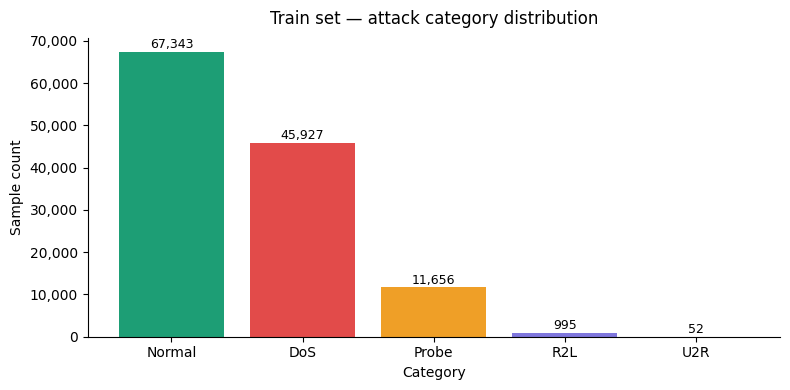

category
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52


In [5]:
# ── Cell 5: EDA — Raw Label Distribution ─────────────────────────────────────
# NSL-KDD labels are fine-grained attack names (e.g. 'neptune', 'portsweep').
# We first look at them raw, then map to 5 coarse categories.

ATTACK_MAP = {
    # Normal
    "normal": "Normal",
    # DoS
    "back": "DoS", "land": "DoS", "neptune": "DoS", "pod": "DoS",
    "smurf": "DoS", "teardrop": "DoS", "mailbomb": "DoS",
    "apache2": "DoS", "processtable": "DoS", "udpstorm": "DoS",
    # Probe
    "ipsweep": "Probe", "nmap": "Probe", "portsweep": "Probe",
    "satan": "Probe", "mscan": "Probe", "saint": "Probe",
    # R2L
    "ftp_write": "R2L", "guess_passwd": "R2L", "imap": "R2L",
    "multihop": "R2L", "phf": "R2L", "spy": "R2L", "warezclient": "R2L",
    "warezmaster": "R2L", "sendmail": "R2L", "named": "R2L",
    "snmpgetattack": "R2L", "snmpguess": "R2L", "worm": "R2L",
    "xlock": "R2L", "xsnoop": "R2L", "httptunnel": "R2L",
    # U2R
    "buffer_overflow": "U2R", "loadmodule": "U2R", "perl": "U2R",
    "rootkit": "U2R", "ps": "U2R", "sqlattack": "U2R",
    "xterm": "U2R"
}

df_train["category"] = df_train["label"].map(ATTACK_MAP).fillna("Other")
df_test["category"]  = df_test["label"].map(ATTACK_MAP).fillna("Other")

# ── Plot 1: Coarse category counts ───────────────────────────────────────────
cat_counts = df_train["category"].value_counts()

colors = {
    "Normal": "#1D9E75",
    "DoS":    "#E24B4A",
    "Probe":  "#EF9F27",
    "R2L":    "#7F77DD",
    "U2R":    "#D85A30",
    "Other":  "#888780",
}
bar_colors = [colors.get(c, "#888780") for c in cat_counts.index]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(cat_counts.index, cat_counts.values, color=bar_colors, edgecolor="none")

for bar, val in zip(bars, cat_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
        f"{val:,}", ha="center", va="bottom", fontsize=9
    )

ax.set_title("Train set — attack category distribution", fontsize=12, pad=10)
ax.set_xlabel("Category")
ax.set_ylabel("Sample count")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(PROC_DIR, "eda_category_distribution.png"), dpi=120)
plt.show()
print(cat_counts.to_string())

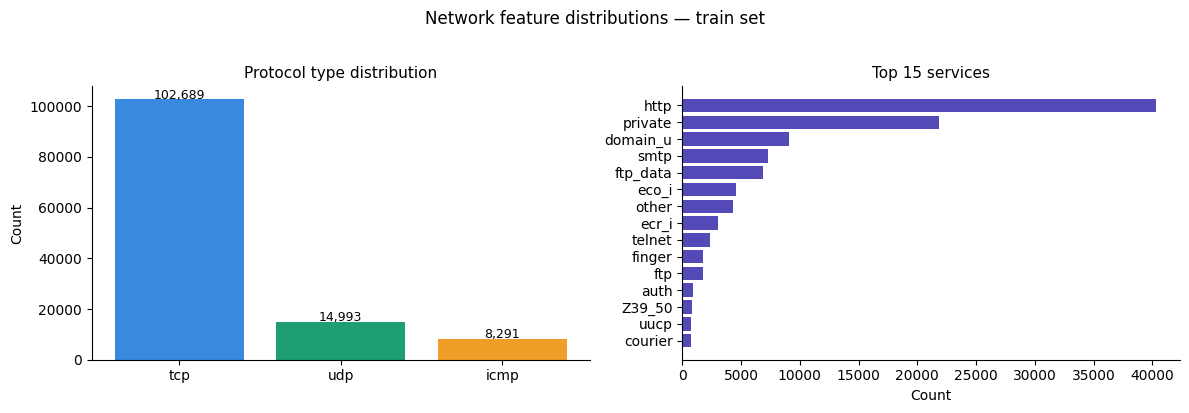

In [6]:
# ── Cell 6: EDA — Protocol & Service Distribution ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Protocol type
proto_counts = df_train["protocol_type"].value_counts()
axes[0].bar(proto_counts.index, proto_counts.values,
            color=["#378ADD", "#1D9E75", "#EF9F27"], edgecolor="none")
axes[0].set_title("Protocol type distribution", fontsize=11)
axes[0].set_ylabel("Count")
axes[0].spines[["top", "right"]].set_visible(False)
for i, v in enumerate(proto_counts.values):
    axes[0].text(i, v + 100, f"{v:,}", ha="center", fontsize=9)

# Top 15 services
svc_counts = df_train["service"].value_counts().head(15)
axes[1].barh(svc_counts.index[::-1], svc_counts.values[::-1],
             color="#534AB7", edgecolor="none")
axes[1].set_title("Top 15 services", fontsize=11)
axes[1].set_xlabel("Count")
axes[1].spines[["top", "right"]].set_visible(False)

plt.suptitle("Network feature distributions — train set", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PROC_DIR, "eda_protocol_service.png"), dpi=120)
plt.show()

In [7]:
# ── Cell 7: EDA — Class Imbalance Summary ────────────────────────────────────
print("TRAIN set — category breakdown")
print("─" * 40)
total_train = len(df_train)
for cat, cnt in df_train["category"].value_counts().items():
    pct = cnt / total_train * 100
    bar = "█" * int(pct / 2)
    print(f"  {cat:<10} {cnt:>7,}  ({pct:5.1f}%)  {bar}")

print(f"\n  Total: {total_train:,}")

print("\nTEST set — category breakdown")
print("─" * 40)
total_test = len(df_test)
for cat, cnt in df_test["category"].value_counts().items():
    pct = cnt / total_test * 100
    bar = "█" * int(pct / 2)
    print(f"  {cat:<10} {cnt:>7,}  ({pct:5.1f}%)  {bar}")
print(f"\n  Total: {total_test:,}")

print("\n⚠️  Note: U2R and R2L are highly underrepresented.")
print("    Phase 3 will address this with class weights or oversampling.")

TRAIN set — category breakdown
────────────────────────────────────────
  Normal      67,343  ( 53.5%)  ██████████████████████████
  DoS         45,927  ( 36.5%)  ██████████████████
  Probe       11,656  (  9.3%)  ████
  R2L            995  (  0.8%)  
  U2R             52  (  0.0%)  

  Total: 125,973

TEST set — category breakdown
────────────────────────────────────────
  Normal       9,710  ( 43.1%)  █████████████████████
  DoS          7,458  ( 33.1%)  ████████████████
  R2L          2,887  ( 12.8%)  ██████
  Probe        2,421  ( 10.7%)  █████
  U2R             67  (  0.3%)  

  Total: 22,543

⚠️  Note: U2R and R2L are highly underrepresented.
    Phase 3 will address this with class weights or oversampling.


In [8]:
# ── Cell 8: Cleaning ─────────────────────────────────────────────────────────
# Steps: replace inf → NaN, drop NaN rows, drop duplicates.
# The 'category' column we added for EDA is also dropped here.

def clean(df, name):
    n0 = len(df)
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna()
    df = df.drop_duplicates()
    df = df.drop(columns=["category"], errors="ignore")
    print(f"{name}: {n0:,} → {len(df):,} rows  (removed {n0 - len(df):,})")
    return df.reset_index(drop=True)

df_train = clean(df_train, "Train")
df_test  = clean(df_test,  "Test")

Train: 125,973 → 125,973 rows  (removed 0)


Test: 22,543 → 22,543 rows  (removed 0)


In [9]:
# ── Cell 9: Label Encoding ───────────────────────────────────────────────────
# Categorical columns: protocol_type, service, flag.
# IMPORTANT: fit the encoder on the union of train + test values.
# This ensures test-only categories (e.g. rare services) don't cause
# unseen-label errors at transform time.
#
# The 'label' column (attack name) is also encoded to integer class IDs.

CAT_COLS = ["protocol_type", "service", "flag"]

encoders = {}

for col in CAT_COLS:
    le = LabelEncoder()
    combined = pd.concat([df_train[col], df_test[col]], ignore_index=True)
    le.fit(combined)
    df_train[col] = le.transform(df_train[col])
    df_test[col]  = le.transform(df_test[col])
    encoders[col] = le
    print(f"  {col:<20} → {len(le.classes_)} classes: {list(le.classes_[:6])}{'...' if len(le.classes_) > 6 else ''}")

# Encode the label column
le_label = LabelEncoder()
combined_labels = pd.concat([df_train["label"], df_test["label"]], ignore_index=True)
le_label.fit(combined_labels)
df_train["label"] = le_label.transform(df_train["label"])
df_test["label"]  = le_label.transform(df_test["label"])
encoders["label"] = le_label

print(f"\n  label               → {len(le_label.classes_)} classes")
print(f"  Class 0 = '{le_label.classes_[0]}'  (verify this is 'normal' or check order)")
print("\nLabel encoding complete. All columns are now numeric.")

  protocol_type        → 3 classes: ['icmp', 'tcp', 'udp']
  service              → 70 classes: ['IRC', 'X11', 'Z39_50', 'aol', 'auth', 'bgp']...
  flag                 → 11 classes: ['OTH', 'REJ', 'RSTO', 'RSTOS0', 'RSTR', 'S0']...

  label               → 40 classes
  Class 0 = 'apache2'  (verify this is 'normal' or check order)

Label encoding complete. All columns are now numeric.


In [10]:
# ── Cell 10: Feature / Label Split ───────────────────────────────────────────
FEATURE_COLS = [c for c in df_train.columns if c != "label"]
assert len(FEATURE_COLS) == 41, f"Expected 41 features, got {len(FEATURE_COLS)}"

X_train_raw = df_train[FEATURE_COLS].values.astype(np.float32)
y_train_raw = df_train["label"].values.astype(np.int32)

X_test_raw  = df_test[FEATURE_COLS].values.astype(np.float32)
y_test_raw  = df_test["label"].values.astype(np.int32)

print(f"X_train_raw : {X_train_raw.shape}  dtype={X_train_raw.dtype}")
print(f"y_train_raw : {y_train_raw.shape}  dtype={y_train_raw.dtype}")
print(f"X_test_raw  : {X_test_raw.shape}   dtype={X_test_raw.dtype}")
print(f"y_test_raw  : {y_test_raw.shape}   dtype={y_test_raw.dtype}")

X_train_raw : (125973, 41)  dtype=float32
y_train_raw : (125973,)  dtype=int32
X_test_raw  : (22543, 41)   dtype=float32
y_test_raw  : (22543,)   dtype=int32


In [11]:
# ── Cell 11: Normalization (MinMaxScaler) ─────────────────────────────────────
# ⚠️  Critical rule: fit ONLY on training data, transform both.
# Fitting on test data would leak future information into the model.

scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(X_train_raw)                      # fit on train only

X_train_scaled = scaler.transform(X_train_raw).astype(np.float32)
X_test_scaled  = scaler.transform(X_test_raw).astype(np.float32)

print(f"X_train_scaled: min={X_train_scaled.min():.4f}  max={X_train_scaled.max():.4f}")
print(f"X_test_scaled : min={X_test_scaled.min():.4f}  max={X_test_scaled.max():.4f}")
print("\n✅  Scaler fitted on train only — no data leakage.")

# Sanity: test values CAN exceed [0,1] if they fall outside the train range.
# That is expected and correct — do NOT clip unless you have a specific reason.
out_of_range = ((X_test_scaled < 0) | (X_test_scaled > 1)).sum()
print(f"   Test values outside [0,1]: {out_of_range} (expected for unseen data)")

X_train_scaled: min=0.0000  max=1.0000
X_test_scaled : min=0.0000  max=2.5000

✅  Scaler fitted on train only — no data leakage.
   Test values outside [0,1]: 7 (expected for unseen data)


In [12]:
# ── Cell 12: Sliding Window Construction ─────────────────────────────────────
# Groups T=10 consecutive rows into one sequence.
# Label of each window = label of its LAST row.
#
# Output shapes:
#   X  → (num_windows, T, 41)
#   y  → (num_windows,)

T = 10  # window / time-steps

def sliding_window(X, y, T=10):
    """
    Parameters
    ----------
    X : np.ndarray  shape (N, features)
    y : np.ndarray  shape (N,)
    T : int         window length

    Returns
    -------
    X_win : np.ndarray  shape (N-T+1, T, features)
    y_win : np.ndarray  shape (N-T+1,)  — label of last row in window
    """
    N, F = X.shape
    num_windows = N - T + 1
    X_win = np.lib.stride_tricks.sliding_window_view(X, (T, F)).reshape(num_windows, T, F)
    y_win = y[T - 1:]   # label aligned to the last timestep
    return X_win.astype(np.float32), y_win.astype(np.int32)

X_train, y_train = sliding_window(X_train_scaled, y_train_raw, T)
X_test,  y_test  = sliding_window(X_test_scaled,  y_test_raw,  T)

print(f"X_train : {X_train.shape}   dtype={X_train.dtype}")
print(f"y_train : {y_train.shape}   dtype={y_train.dtype}")
print(f"X_test  : {X_test.shape}    dtype={X_test.dtype}")
print(f"y_test  : {y_test.shape}    dtype={y_test.dtype}")
print(f"\nExpected shape: (samples, {T}, 41)  ✅")

X_train : (125964, 10, 41)   dtype=float32
y_train : (125964,)   dtype=int32
X_test  : (22534, 10, 41)    dtype=float32
y_test  : (22534,)    dtype=int32

Expected shape: (samples, 10, 41)  ✅


In [13]:
# ── Cell 13: Save Processed Arrays ───────────────────────────────────────────
files = {
    "X_train.npy": X_train,
    "y_train.npy": y_train,
    "X_test.npy":  X_test,
    "y_test.npy":  y_test,
}

for fname, arr in files.items():
    path = os.path.join(PROC_DIR, fname)
    np.save(path, arr)
    size_mb = os.path.getsize(path) / (1024 ** 2)
    print(f"  Saved  {fname:<20} shape={str(arr.shape):<25} {size_mb:.1f} MB")

print(f"\n✅  All arrays saved to  {PROC_DIR}")
print("    These are the inputs for Phase 3 — LSTM-CNN training.")

  Saved  X_train.npy          shape=(125964, 10, 41)          197.0 MB
  Saved  y_train.npy          shape=(125964,)                 0.5 MB


In [14]:
# ── Cell 14: Verification — Reload & Sanity Check ────────────────────────────
# Always verify saves by reloading from disk.

X_train_v = np.load(os.path.join(PROC_DIR, "X_train.npy"))
y_train_v = np.load(os.path.join(PROC_DIR, "y_train.npy"))
X_test_v  = np.load(os.path.join(PROC_DIR, "X_test.npy"))
y_test_v  = np.load(os.path.join(PROC_DIR, "y_test.npy"))

checks = [
    ("X_train dims",  X_train_v.ndim == 3,           f"ndim={X_train_v.ndim}"),
    ("X_train T=10",  X_train_v.shape[1] == 10,      f"shape[1]={X_train_v.shape[1]}"),
    ("X_train F=41",  X_train_v.shape[2] == 41,      f"shape[2]={X_train_v.shape[2]}"),
    ("y_train 1D",    y_train_v.ndim == 1,            f"ndim={y_train_v.ndim}"),
    ("X/y train len", len(X_train_v) == len(y_train_v), f"{len(X_train_v)} vs {len(y_train_v)}"),
    ("X/y test len",  len(X_test_v)  == len(y_test_v),  f"{len(X_test_v)} vs {len(y_test_v)}"),
    ("dtype float32", X_train_v.dtype == np.float32,   f"dtype={X_train_v.dtype}"),
]

all_ok = True
for name, passed, detail in checks:
    icon = "✅" if passed else "❌"
    print(f"  {icon}  {name:<22}  {detail}")
    if not passed:
        all_ok = False

print()
if all_ok:
    print("Phase 2 complete. Ready for Phase 3 — LSTM-CNN training.")
else:
    print("❌  One or more checks failed. Review the cells above.")

  ✅  X_train dims            ndim=3
  ✅  X_train T=10            shape[1]=10
  ✅  X_train F=41            shape[2]=41
  ✅  y_train 1D              ndim=1
  ✅  X/y train len           125964 vs 125964
  ✅  X/y test len            22534 vs 22534
  ✅  dtype float32           dtype=float32

Phase 2 complete. Ready for Phase 3 — LSTM-CNN training.


---
## Phase 2 Summary

| Step | Action | Output |
|------|--------|--------|
| Load | 42-col CSV, drop `difficulty_level` | `df_train`, `df_test` (41 features + label) |
| EDA | Category/protocol/service plots | PNG charts in `processed/` |
| Clean | Drop `inf`/`NaN`, remove duplicates | Reduced row counts |
| Encode | `LabelEncoder` on 3 cat cols + label | All columns numeric |
| Scale | `MinMaxScaler` fit on train only | `X_*_scaled` |
| Window | T=10 sliding window, label = last row | `(samples, 10, 41)` |
| Save | `.npy` arrays | `data/processed/` |

**Key principle preserved:** Scaler fit on training data only → no data leakage into test set.

**Next:** Phase 3 — build `src/models/lstm_cnn.py` and `training/train_lstm_cnn.py`

In [15]:
# Cell N+1 — Phase 5 prep: persist v1 scaler + encoders
# (Added after Phase 4 complete; rebuilds the in-memory objects that
#  produced X_train.npy back in April 2026.)

import joblib
from pathlib import Path

OUT_DIR = Path(os.environ.get("RL_FIREWALL_DATA", "./data")) / "processed"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# 1. Persist the MinMaxScaler from Cell 11
scaler_path = OUT_DIR / "scaler_v1.joblib"
joblib.dump(scaler, scaler_path)
print(f"✓ Saved scaler → {scaler_path}")
print(f"  data_min_ shape: {scaler.data_min_.shape}")
print(f"  data_max_ shape: {scaler.data_max_.shape}")
print(f"  feature_range: {scaler.feature_range}")

# 2. Persist the encoders dict from Cell 9
encoders_path = OUT_DIR / "encoders_v1.joblib"
joblib.dump(encoders, encoders_path)
print(f"\n✓ Saved encoders → {encoders_path}")
for col, le in encoders.items():
    print(f"  {col}: {len(le.classes_)} classes  (first 5: {list(le.classes_[:5])})")

# 3. Sanity check — apply rebuilt scaler to one raw row, compare against X_train.npy
import numpy as np
X_train_v1 = np.load(OUT_DIR / "X_train.npy")
print(f"\nX_train.npy shape: {X_train_v1.shape}")
print(f"X_train.npy[0, 0, :5]:        {X_train_v1[0, 0, :5]}")  # first 5 features of first window

# Re-derive the scaled features from the raw post-encoded df_train and compare
# (df_train is already encoded after Cell 9; the scaler in Cell 11 was fit on those)
X_train_raw_full = df_train[FEATURE_COLS].values  # same construction as Cell 11
X_train_scaled_check = scaler.transform(X_train_raw_full).astype(np.float32)
print(f"Rebuilt scaled[0, :5]:         {X_train_scaled_check[0, :5]}")

# The very first row of df_train is also the very first time-step of the very
# first window in X_train.npy (windowing keeps original row order; the [0,0,:]
# slice == the scaled version of df_train.iloc[0]).
match = np.allclose(X_train_v1[0, 0, :], X_train_scaled_check[0, :], atol=1e-6)
print(f"\n{'✓' if match else '✗'} Bit-identical reproduction of X_train.npy[0, 0, :]")
assert match, "Scaler regenerated does NOT match v1 — investigate before Phase 5"
print("\nPhase 5 unblocked: scaler_v1.joblib + encoders_v1.joblib reproduce v1 preprocessing.")


X_train.npy shape: (125964, 10, 41)
X_train.npy[0, 0, :5]:        [0.0000000e+00 5.0000000e-01 2.8985506e-01 9.0000004e-01 3.5580641e-07]
Rebuilt scaled[0, :5]:         [0.0000000e+00 5.0000000e-01 2.8985506e-01 9.0000004e-01 3.5580641e-07]

✓ Bit-identical reproduction of X_train.npy[0, 0, :]

Phase 5 unblocked: scaler_v1.joblib + encoders_v1.joblib reproduce v1 preprocessing.
